In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from dowhy import CausalModel
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
from dowhy import CausalModel, gcm
import graphviz
import seaborn as sns
import scipy.stats as stats

In [4]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
print(len(df))
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)]
print(len(df))
df.head()

6140
5612


,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670


In [5]:
df["verdict"] = df["verdict"].astype(int)
# df["apk_size_mb"] = df["apk_size"] / 1000000
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["lib_category"] = df["code_location"].apply(lambda x: x if x != "developer_written" else "source")

df["verdict"].value_counts()
df.head()

,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size,is_third_party,lib_category
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,1,others
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,1,others
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,1,Android
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,1,Android
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670,1,Android


In [6]:
df["verdict"].value_counts()

verdict
0    2898
1    2714
Name: count, dtype: int64

In [7]:
df["code_location"].value_counts()

code_location
Utilities            3039
others               1341
developer_written     511
Android               494
SocialMedia           180
Analytics              34
Cloud                  13
Name: count, dtype: int64

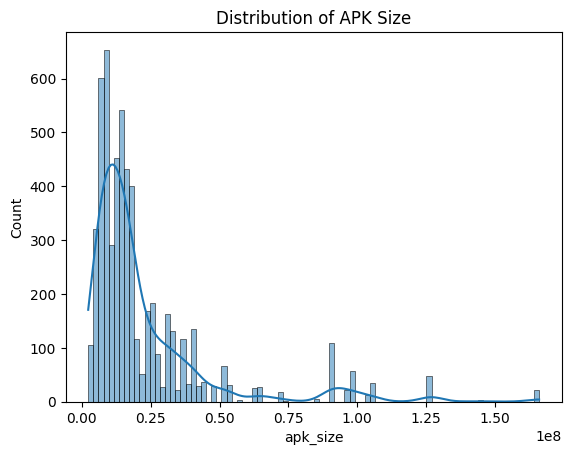

In [8]:
sns.histplot(df["apk_size"], kde=True)
plt.title("Distribution of APK Size")
plt.xlabel("apk_size")
plt.show()


In [9]:
### Normalization of apk_size (we are using the RobustScaler here, because apk_size has some outliers and right skewed distribution)

# from sklearn.preprocessing import MinMaxScaler

# df_scaled = df.copy()
# scaler = MinMaxScaler()
# df_scaled["apk_size_scaled"] = scaler.fit_transform(df_scaled[["apk_size"]])
# df_scaled["apk_size_scaled"].describe()



from sklearn.preprocessing import RobustScaler

df_scaled = df.copy()
scaler = RobustScaler()
df_scaled["apk_size_scaled"] = scaler.fit_transform(df_scaled[["apk_size"]])
df_scaled["apk_size_scaled"].describe()


count    5612.000000
mean        0.489310
std         1.437216
min        -0.719854
25%        -0.336389
50%         0.000000
75%         0.663611
max         9.086488
Name: apk_size_scaled, dtype: float64

In [10]:
### boostrap resampling to estimate mean and 95% CI

n_bootstraps = 1000  
boot_means = {
    "apk_size_scaled": [],
    "verdict": [],
    "is_third_party": [],
}

for i in range(n_bootstraps):
    boot_sample = df_scaled.sample(frac=1, replace=True, random_state=i)
    
    boot_means["apk_size_scaled"].append(boot_sample["apk_size_scaled"].mean())
    boot_means["verdict"].append(boot_sample["verdict"].mean())
    boot_means["is_third_party"].append(boot_sample["is_third_party"].mean())


summary = {}
for col, values in boot_means.items():
    values = np.array(values)
    summary[col] = {
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "95% CI lower": np.percentile(values, 2.5),
        "95% CI upper": np.percentile(values, 97.5)
    }

summary_df = pd.DataFrame(summary).T
summary_df


,mean,std,95% CI lower,95% CI upper
apk_size_scaled,0.489775,0.019647,0.452419,0.526207
verdict,0.483788,0.006595,0.470594,0.496445
is_third_party,0.908838,0.004000,0.901283,0.916607


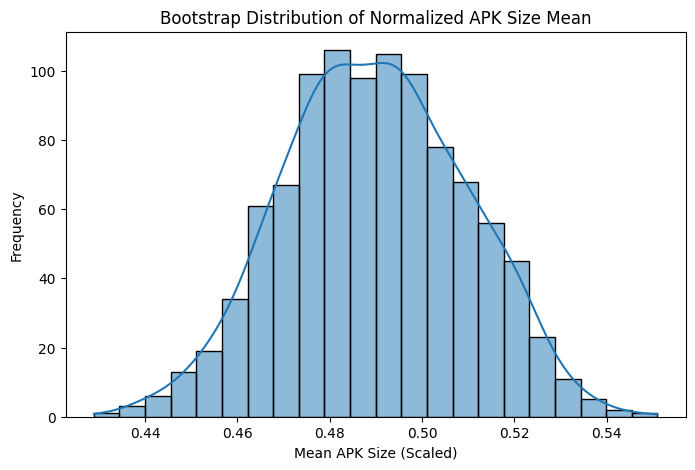

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(boot_means["apk_size_scaled"], kde=True)
plt.title("Bootstrap Distribution of Normalized APK Size Mean")
plt.xlabel("Mean APK Size (Scaled)")
plt.ylabel("Frequency")
plt.show()


In [12]:
### selecting a random bootstrap sample for further analysis

boot_sample_final = df_scaled.sample(frac=1, replace=True, random_state=42)
boot_sample_final.head()


,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size,is_third_party,lib_category,apk_size_scaled
945,Third parameter was not properly generated as ...,0,okhttp3/OkHttpClient.java,com.aryservices.arynews.en,80970,>5M,CogniCrypt,Utilities,OkHttp,15484951,1,Utilities,0.070908
5866,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcis.java,so.ateya.ahmed.Lagna_Daamah,4,10k-50k,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,15706506,1,Android,0.084175
5690,Third parameter was not properly generated as ...,0,okhttp3/OkHttpClient.java,pt.iol.tviplayer.android,314,1M-5M,CogniCrypt,Utilities,OkHttp,23257099,1,Utilities,0.536289
5655,First parameter was not properly generated as ...,0,okhttp3/internal/platform/Platform.java,pt.cp.mobiapp,285,1M-5M,CogniCrypt,Utilities,OkHttp,25170435,1,Utilities,0.650856
4071,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/simplexi/messenger/DeviceUnique.java,com.simplexi.messenger,2021020104,10k-50k,CogniCrypt,developer_written,not_applicable,9590491,0,source,-0.282040


In [13]:
### As our treatment variable is imbalanced, we will now create a balanced sample for analysis based on treatment variable

third_party = boot_sample_final[boot_sample_final["is_third_party"] == 1]
developer_written = boot_sample_final[boot_sample_final["is_third_party"] == 0]

n_samples = min(len(third_party), len(developer_written))
balanced_sample = pd.concat([
    third_party.sample(n=n_samples, replace=True, random_state=1),
    developer_written.sample(n=n_samples, replace=True, random_state=2)
])

print("Balanced sample size:", len(balanced_sample))
balanced_sample["is_third_party"].value_counts(normalize=True)


Balanced sample size: 1006


is_third_party
1    0.5
0    0.5
Name: proportion, dtype: float64

In [14]:
balanced_sample["lib_category"].value_counts()

lib_category
source         503
Utilities      310
others         139
Android         40
SocialMedia     12
Cloud            1
Analytics        1
Name: count, dtype: int64

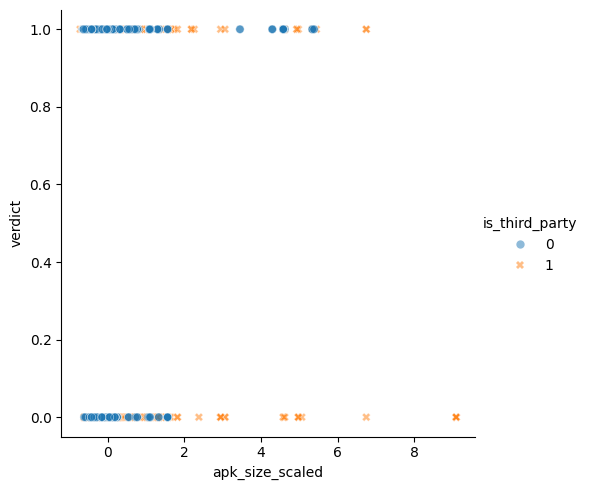

In [15]:
sns.relplot(
    data=balanced_sample,
    x="apk_size_scaled",
    y="verdict",
    hue="is_third_party",
    alpha=0.5,
    style="is_third_party",
)

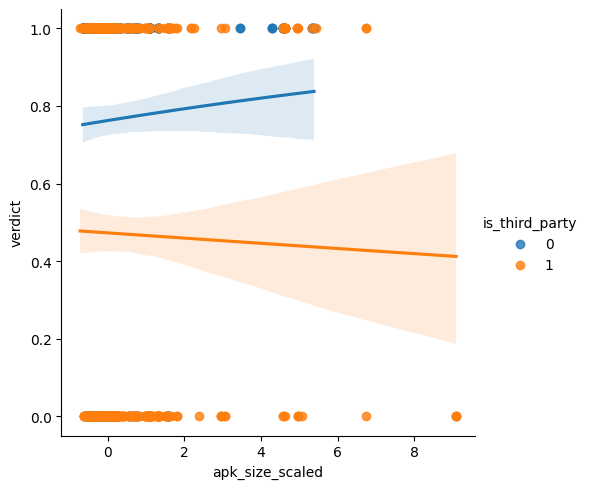

In [16]:
sns.lmplot(
    data=balanced_sample,
    x="apk_size_scaled",
    y="verdict",
    hue="is_third_party",
    logistic=True,
    ci=95
)


In [17]:
category_order = ['<100','100-500','500-1k','1k-5k','5k-10k','10k-50k',
                  '50k-100k','100k-500k','500k-1M','1M-5M','>5M']

ord_map = {c:i for i, c in enumerate(category_order)}
balanced_sample['apk_category_encoded'] = balanced_sample['apk_category'].map(ord_map)

balanced_sample.head()

,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size,is_third_party,lib_category,apk_size_scaled,apk_category_encoded
3475,First parameter was not properly generated as ...,0,okhttp3/internal/Util.java,com.pegasustech.smartstores,10,<100,CogniCrypt,Utilities,OkHttp,13968266,1,Utilities,-0.019908,0
2768,Third parameter was not properly generated as ...,1,com/digitalturbine/ignite/encryption/a.java,com.kumobius.android.walljumper,23,>5M,CogniCrypt,others,unknown,30515096,1,others,0.970884,10
1809,First parameter was not properly generated as ...,0,org/apache/http/conn/ssl/SSLSocketFactory.java,com.etms.employee,15,1k-5k,CogniCrypt,Utilities,apache-httpclient-android,7673460,1,Utilities,-0.396828,3
1657,"Constraint ""protocol in {TLSv1.2, TLSv1.3}"" on...",1,okhttp3/internal/platform/Platform.java,com.dieffetech.eolas,2,<100,CogniCrypt,Utilities,OkHttp,9864241,1,Utilities,-0.265649,0
2173,First parameter was not properly generated as ...,1,LossIssuingDiscovery/SpeedBannerHorizontal.java,com.free.neo.vpn,77761,>5M,CogniCrypt,others,unknown,13024363,1,others,-0.076427,10


In [36]:
balanced_sample["apk_category_encoded"].value_counts()

apk_category_encoded
0     134
8     117
7     110
1     107
9      96
6      84
2      81
5      76
10     75
3      70
4      56
Name: count, dtype: int64

In [37]:
balanced_sample["apk_category"].value_counts()

apk_category
<100         134
500k-1M      117
100k-500k    110
100-500      107
1M-5M         96
50k-100k      84
500-1k        81
10k-50k       76
>5M           75
1k-5k         70
5k-10k        56
Name: count, dtype: int64

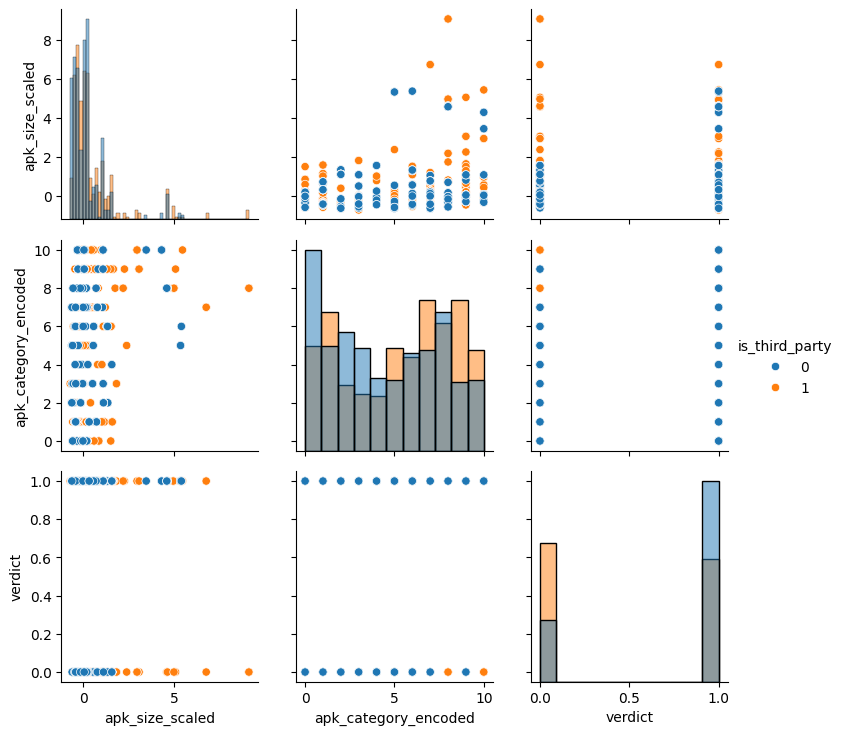

In [18]:
cols = ["apk_size_scaled", "apk_category_encoded", "verdict", "is_third_party"]

g = sns.PairGrid(balanced_sample[cols], hue="is_third_party", diag_sharey=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()


# g = sns.PairGrid(balanced_sample, hue="is_third_party", diag_sharey=False)
# g.map_diag(sns.histplot)
# g.map_offdiag(sns.scatterplot)
# g.add_legend()

In [19]:
balanced_sample.head()

,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size,is_third_party,lib_category,apk_size_scaled,apk_category_encoded
3475,First parameter was not properly generated as ...,0,okhttp3/internal/Util.java,com.pegasustech.smartstores,10,<100,CogniCrypt,Utilities,OkHttp,13968266,1,Utilities,-0.019908,0
2768,Third parameter was not properly generated as ...,1,com/digitalturbine/ignite/encryption/a.java,com.kumobius.android.walljumper,23,>5M,CogniCrypt,others,unknown,30515096,1,others,0.970884,10
1809,First parameter was not properly generated as ...,0,org/apache/http/conn/ssl/SSLSocketFactory.java,com.etms.employee,15,1k-5k,CogniCrypt,Utilities,apache-httpclient-android,7673460,1,Utilities,-0.396828,3
1657,"Constraint ""protocol in {TLSv1.2, TLSv1.3}"" on...",1,okhttp3/internal/platform/Platform.java,com.dieffetech.eolas,2,<100,CogniCrypt,Utilities,OkHttp,9864241,1,Utilities,-0.265649,0
2173,First parameter was not properly generated as ...,1,LossIssuingDiscovery/SpeedBannerHorizontal.java,com.free.neo.vpn,77761,>5M,CogniCrypt,others,unknown,13024363,1,others,-0.076427,10


In [20]:
balanced_sample["verdict"].value_counts()

verdict
1    621
0    385
Name: count, dtype: int64

In [21]:
balanced_sample["apk_category"].value_counts()

apk_category
<100         134
500k-1M      117
100k-500k    110
100-500      107
1M-5M         96
50k-100k      84
500-1k        81
10k-50k       76
>5M           75
1k-5k         70
5k-10k        56
Name: count, dtype: int64

In [22]:
balanced_sample["is_third_party"].value_counts()

is_third_party
1    503
0    503
Name: count, dtype: int64

In [23]:

causal_graph = """
digraph {
    is_third_party -> verdict;
    apk_size_scaled -> is_third_party;
    apk_size_scaled -> verdict;
    apk_category -> is_third_party;
    apk_category -> verdict;
}
"""

causal_graph_2 = """
digraph {
    is_third_party -> verdict;
    apk_size_scaled -> is_third_party;
    apk_size_scaled -> verdict;
    apk_category -> is_third_party;
    apk_category -> verdict;
    apk_category -> apk_size_scaled;
}
"""

causal_graph_only_size = """
digraph {
    apk_size_scaled -> is_third_party;
    apk_size_scaled -> verdict;
    is_third_party -> verdict;
}
"""

causal_graph_only_apk_category = """
digraph {
    is_third_party -> verdict;
    apk_category -> is_third_party;
    apk_category -> verdict;
}
"""


causal_graph_after_correlation_test = """
digraph {
    is_third_party -> verdict;
    apk_size_scaled -> is_third_party;
    apk_category -> is_third_party;
    apk_category -> verdict;
    apk_category -> apk_size_scaled;
}
"""

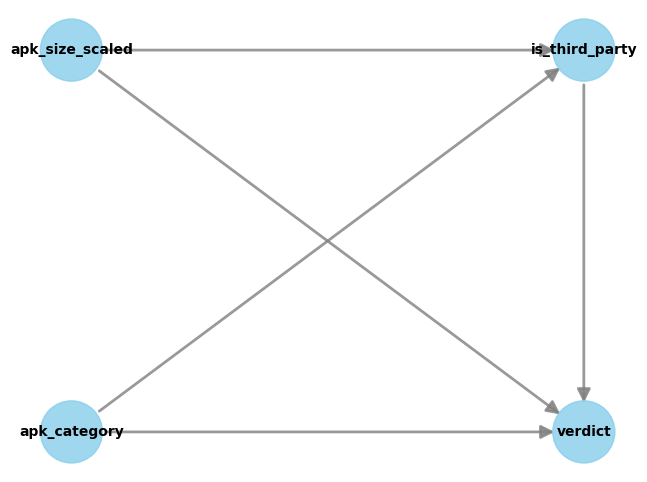

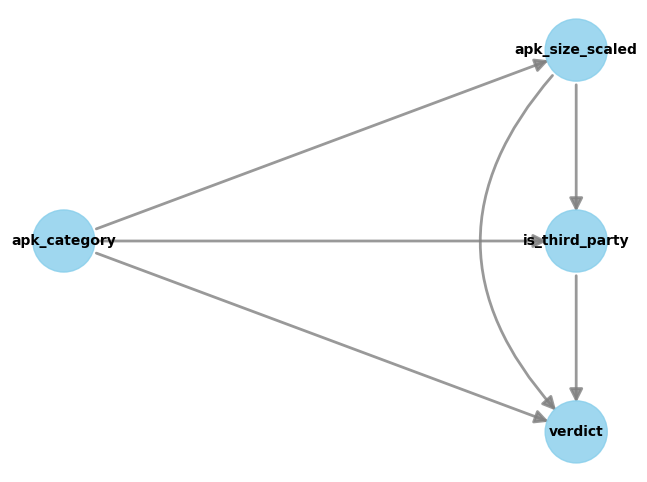

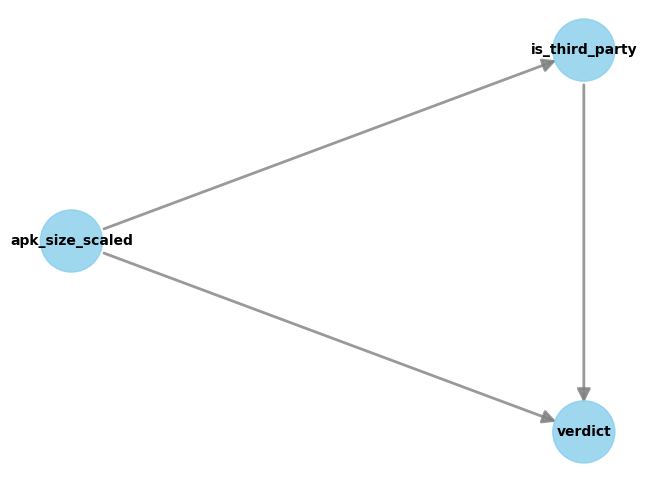

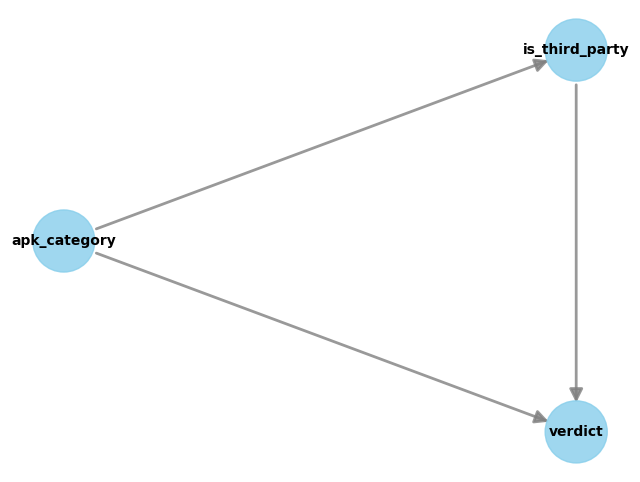

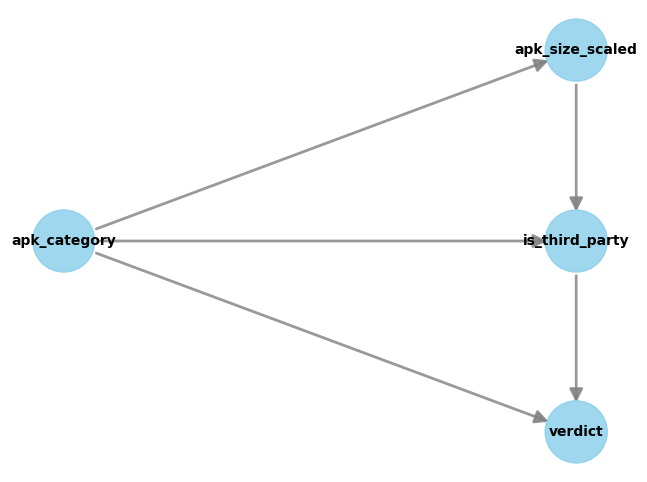

In [24]:
model = CausalModel(
    data=balanced_sample,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph.replace("\n", " "),
    common_causes=["apk_size_scaled", "apk_category"]
)

model_2 = CausalModel(
    data=balanced_sample,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_2.replace("\n", " "),
    common_causes=["apk_size_scaled", "apk_category"]
)

model_only_size = CausalModel(
    data=balanced_sample,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_only_size.replace("\n", " "),
    common_causes=["apk_size_scaled"]
)
    
model_only_apk_category = CausalModel(
    data=balanced_sample,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_only_apk_category.replace("\n", " "),
    common_causes=["apk_category"]
)

model_after_correlation_test = CausalModel(
    data=balanced_sample,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_after_correlation_test.replace("\n", " "),
    common_causes=["apk_category"]
)


model.view_model()
model_2.view_model()
model_only_size.view_model()
model_only_apk_category.view_model()
model_after_correlation_test.view_model()

In [25]:
balanced_sample["apk_category"].value_counts()

apk_category
<100         134
500k-1M      117
100k-500k    110
100-500      107
1M-5M         96
50k-100k      84
500-1k        81
10k-50k       76
>5M           75
1k-5k         70
5k-10k        56
Name: count, dtype: int64

In [26]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_2 = model_2.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_only_size = model_only_size.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_only_apk_category = model_only_apk_category.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_after_correlation_test = model_after_correlation_test.identify_effect(proceed_when_unidentifiable=True)


print(identified_estimand, "\n", "------"*10)
print(identified_estimand_2, "\n", "------"*10)
print(identified_estimand_only_size, "\n", "------"*10)
print(identified_estimand_only_apk_category, "\n", "------"*10)
print(identified_estimand_after_correlation_test)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                 
─────────────────(E[verdict|apk_category,apk_size_scaled])
d[is_third_party]                                         
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_category,apk_size_scaled,U) = P(verdict|is_third_party,apk_category,apk_size_scaled)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                                 
─────────────────(E[verdict|apk_category,apk_size_scaled])
d[is_third_party]                                         
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_category,apk_size_scaled

In [27]:
estimate = model.estimate_effect(identified_estimand, method_name="backdoor.propensity_score_matching", target_units = "ate", confidence_intervals=True)
estimate_2 = model_2.estimate_effect(identified_estimand_2, method_name="backdoor.propensity_score_matching", target_units = "ate", confidence_intervals=True)
estimate_only_size = model_only_size.estimate_effect(identified_estimand_only_size, method_name="backdoor.propensity_score_matching", target_units = "ate")
estimate_only_apk_category = model_only_apk_category.estimate_effect(identified_estimand_only_apk_category, method_name="backdoor.propensity_score_matching", target_units = "ate")
estimate_after_correlation_test = model_after_correlation_test.estimate_effect(identified_estimand_after_correlation_test, method_name="backdoor.propensity_score_matching", target_units = "ate")


print(estimate, "\n", "-------"*10)
print(estimate_2, "\n", "-------"*10)
print(estimate_only_size, "\n", "-------"*10)
print(estimate_only_apk_category, "\n", "-------"*10)
print(estimate_after_correlation_test)


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                 
─────────────────(E[verdict|apk_category,apk_size_scaled])
d[is_third_party]                                         
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_category,apk_size_scaled,U) = P(verdict|is_third_party,apk_category,apk_size_scaled)

## Realized estimand
b: verdict~is_third_party+apk_category+apk_size_scaled
Target units: ate

## Estimate
Mean value: -0.27037773359840955
95.0% confidence interval: (np.float64(-0.3250497017892644), np.float64(-0.14711729622266406))
 
 ----------------------------------------------------------------------
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   

In [28]:
refutation_methods = [
    # "add_unobserved_common_cause",
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]


print("----"*15, "Both size and apk category as confounders", "----"*15)
for method in refutation_methods:
    ref = model.refute_estimate(identified_estimand, estimate, method_name=method)
    print(f"\nRefuter: {method}\n",ref)

print("----"*15, "Both size and apk category as confounders 2", "----"*15)
for method in refutation_methods:
    ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method)
    print(f"\nRefuter: {method}\n",ref)


print("----"*15, "Only size as a confounder", "----"*15)
for method in refutation_methods:
    ref = model_only_size.refute_estimate(identified_estimand_only_size, estimate_only_size, method_name=method)
    print(f"\nRefuter: {method}\n",ref)

print("----"*15, "Only apk category as a confounder", "----"*15)
for method in refutation_methods:
    ref = model_only_apk_category.refute_estimate(identified_estimand_only_apk_category, estimate_only_apk_category, method_name=method)
    print(f"\nRefuter: {method}\n",ref)

print("----"*15, "Refutation after correlation test", "----"*15)
for method in refutation_methods:
    ref = model_after_correlation_test.refute_estimate(identified_estimand_after_correlation_test, estimate_after_correlation_test, method_name=method)
    print(f"\nRefuter: {method}\n",ref)


------------------------------------------------------------ Both size and apk category as confounders ------------------------------------------------------------



Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.27037773359840955
New effect:-0.27037773359840944
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.27037773359840955
New effect:-0.0002584493041749499
p value:0.98


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.27037773359840955
New effect:-0.3012546583850932
p value:0.44

------------------------------------------------------------ Both size and apk category as confounders 2 ------------------------------------------------------------

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.27037773359840955
New effect:-0.27037773359840944
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.27037773359840955
New effect:0.0011431411530815113
p value:0.98


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.270377

In [29]:
# p_value = gcm.independence_test(
#     balanced_sample["apk_size_scaled"].values,
#     balanced_sample["verdict"].values,
#     conditioned_on=balanced_sample["is_third_party"].values, 
#     method='kernel'
# )
# p_value

### Rejected the null hypothesis on: 
# apk_category -> apk_size -> is_third_party
# lib_category -> is_third_party-> verdict
# 

# balanced_sample["lib_category"] balanced_sample["code_location"] balanced_sample["is_third_party"]  .astype("category").cat.codes.values

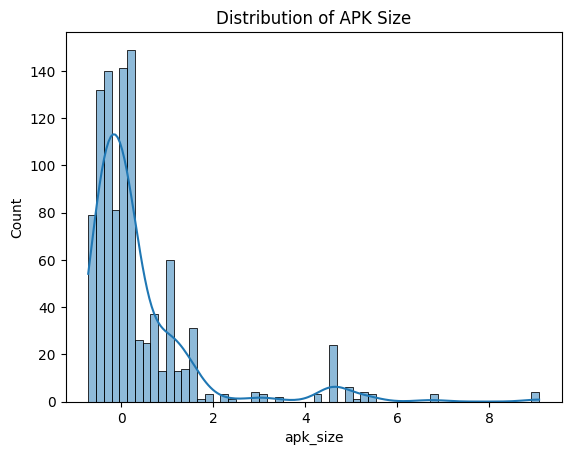

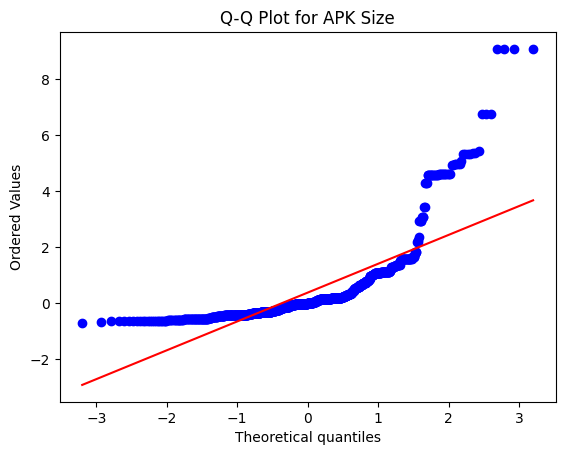

In [30]:

sns.histplot(balanced_sample["apk_size_scaled"], kde=True)
plt.title("Distribution of APK Size")
plt.xlabel("apk_size")
plt.show()

stats.probplot(balanced_sample["apk_size_scaled"], dist="norm", plot=plt)
plt.title("Q-Q Plot for APK Size")
plt.show()


In [31]:
# That means, data is not normally distributed, it is right skewed. So, we can not use the ANOVA, we can use the Kruskal-Wallis H-test (more than 3 independent groups available in our apk_category)) instead for non-parametric data.

In [32]:
balanced_sample.head()

,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size,is_third_party,lib_category,apk_size_scaled,apk_category_encoded,propensity_score
3475,First parameter was not properly generated as ...,0,okhttp3/internal/Util.java,com.pegasustech.smartstores,10,<100,CogniCrypt,Utilities,OkHttp,13968266,1,Utilities,-0.019908,0,0.347631
2768,Third parameter was not properly generated as ...,1,com/digitalturbine/ignite/encryption/a.java,com.kumobius.android.walljumper,23,>5M,CogniCrypt,others,unknown,30515096,1,others,0.970884,10,0.608645
1809,First parameter was not properly generated as ...,0,org/apache/http/conn/ssl/SSLSocketFactory.java,com.etms.employee,15,1k-5k,CogniCrypt,Utilities,apache-httpclient-android,7673460,1,Utilities,-0.396828,3,0.344523
1657,"Constraint ""protocol in {TLSv1.2, TLSv1.3}"" on...",1,okhttp3/internal/platform/Platform.java,com.dieffetech.eolas,2,<100,CogniCrypt,Utilities,OkHttp,9864241,1,Utilities,-0.265649,0,0.336111
2173,First parameter was not properly generated as ...,1,LossIssuingDiscovery/SpeedBannerHorizontal.java,com.free.neo.vpn,77761,>5M,CogniCrypt,others,unknown,13024363,1,others,-0.076427,10,0.555617


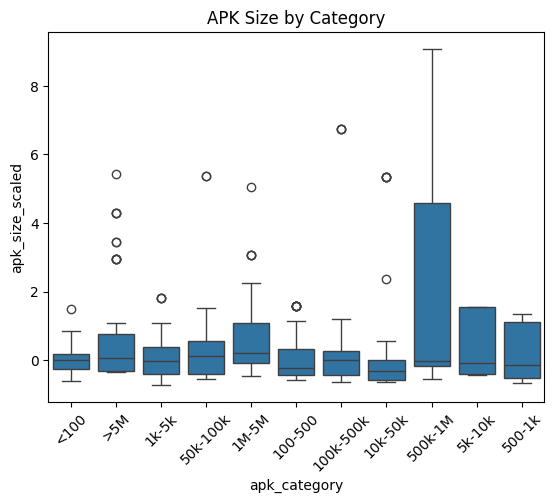

In [33]:
sns.boxplot(x="apk_category", y="apk_size_scaled", data=balanced_sample)
plt.xticks(rotation=45)
plt.title("APK Size by Category")
plt.show()



In [34]:
from scipy.stats import kruskal

groups = [g["apk_size_scaled"].values for _, g in balanced_sample.groupby("apk_category", observed=True)]
H_stat, p_value = kruskal(*groups)

print("-----"*10, "Correlation Test for apk_category -> apk_size", "-----"*10)
print(f"Kruskal–Wallis H = {H_stat:.3f}")
print(f"p-value = {p_value:.5f}")

if p_value < 0.05:
    print("As the p value is less than 0.05, we can say that there is a statistically significant association between the apk_category and apk_size. It provides evidence to support the hypothesis that the apk_category influences apk_size. There is correlation in the apk_category -> apk_size")
else:
    print("\n As the p value is greater than or equal than 0.05, No statistically significant difference detected between APK categories. There is no correlation in the apk_category -> apk_size direction.")



-------------------------------------------------- Correlation Test for apk_category -> apk_size --------------------------------------------------
Kruskal–Wallis H = 66.440
p-value = 0.00000
As the p value is less than 0.05, we can say that there is a statistically significant association between the apk_category and apk_size. It provides evidence to support the hypothesis that the apk_category influences apk_size. There is correlation in the apk_category -> apk_size


In [35]:
from scipy.stats import mannwhitneyu, kruskal

def mann_whitney_test(df, numeric_col, binary_col):
    groups = [df[df[binary_col] == val][numeric_col] for val in df[binary_col].unique()]
    stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    print(f"\n{numeric_col} -> {binary_col}")
    print(f"U = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("Significant difference — likely correlation between variables.")
    else:
        print("No significant difference — weak or no correlation.")
    return stat, p


def kruskal_test(df, cat_col, binary_col):
    groups = [group[binary_col].values for _, group in df.groupby(cat_col)]
    stat, p = kruskal(*groups)
    print(f"\n{cat_col} -> {binary_col}")
    print(f"H = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("Significant difference — likely correlation between variables.")
    else:
        print("No significant difference — weak or no correlation.")
    return stat, p


mann_whitney_test(balanced_sample, "apk_size_scaled", "verdict")
mann_whitney_test(balanced_sample, "apk_size_scaled", "is_third_party")
kruskal_test(balanced_sample, "apk_category", "verdict")
kruskal_test(balanced_sample, "apk_category", "is_third_party")



apk_size_scaled -> verdict
U = 137457.000, p = 0.0001
Significant difference — likely correlation between variables.

apk_size_scaled -> is_third_party
U = 146451.500, p = 0.0000
Significant difference — likely correlation between variables.

apk_category -> verdict
H = 39.252, p = 0.0000
Significant difference — likely correlation between variables.

apk_category -> is_third_party
H = 51.597, p = 0.0000
Significant difference — likely correlation between variables.
